 Initializing SFL-MTKD++ System... Active Device: cuda

Step 1: Loading Actual Kaggle Dataset...

Step 2: Initializing SFL-MTKD++ Topology...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 240MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s] 


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 98.1MB/s]



Step 3: Starting Split Federated Training (20 Rounds)...

────────────────────────────────────────────────────────────────────────────────
 Round 1/20
────────────────────────────────────────────────────────────────────────────────
   [Hospital_0] Train Loss: 0.4377 | Val Acc: 95.7%
   [Hospital_1] Train Loss: 0.3673 | Val Acc: 96.1%
   [Hospital_2] Train Loss: 0.3653 | Val Acc: 95.2%
   [Hospital_3] Train Loss: 0.3574 | Val Acc: 96.1%
   [Hospital_4] Train Loss: 0.3670 | Val Acc: 95.8%

   -> TrustFed Weights: ['0.200', '0.201', '0.199', '0.201', '0.200']
   -> Global Validation Accuracy: 96.08% | Loss: 0.1870

────────────────────────────────────────────────────────────────────────────────
 Round 2/20
────────────────────────────────────────────────────────────────────────────────
   [Hospital_0] Train Loss: 0.3172 | Val Acc: 96.5%
   [Hospital_1] Train Loss: 0.3207 | Val Acc: 96.8%
   [Hospital_2] Train Loss: 0.3283 | Val Acc: 95.0%
   [Hospital_3] Train Loss: 0.3292 | Val Acc: 96.

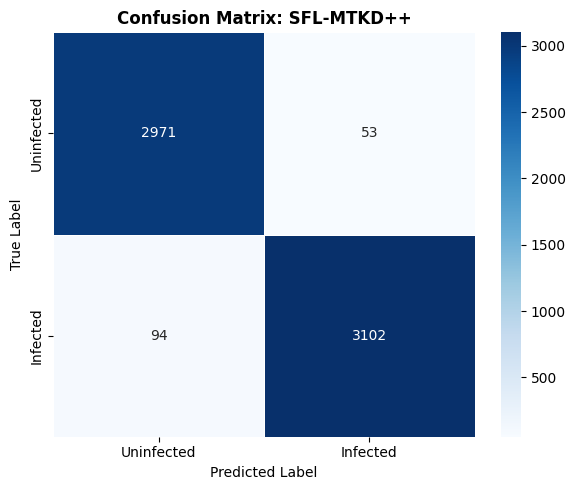

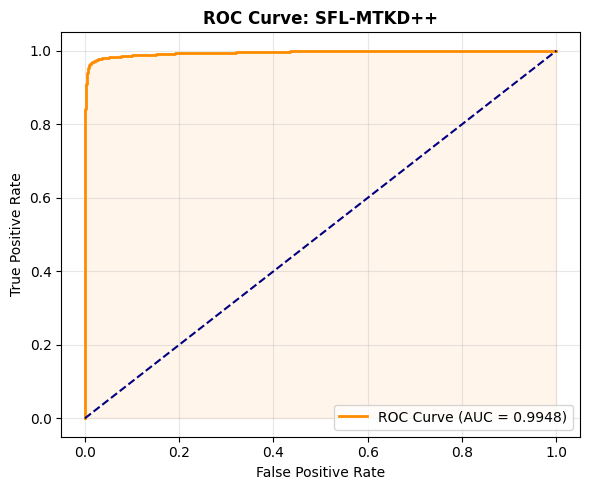

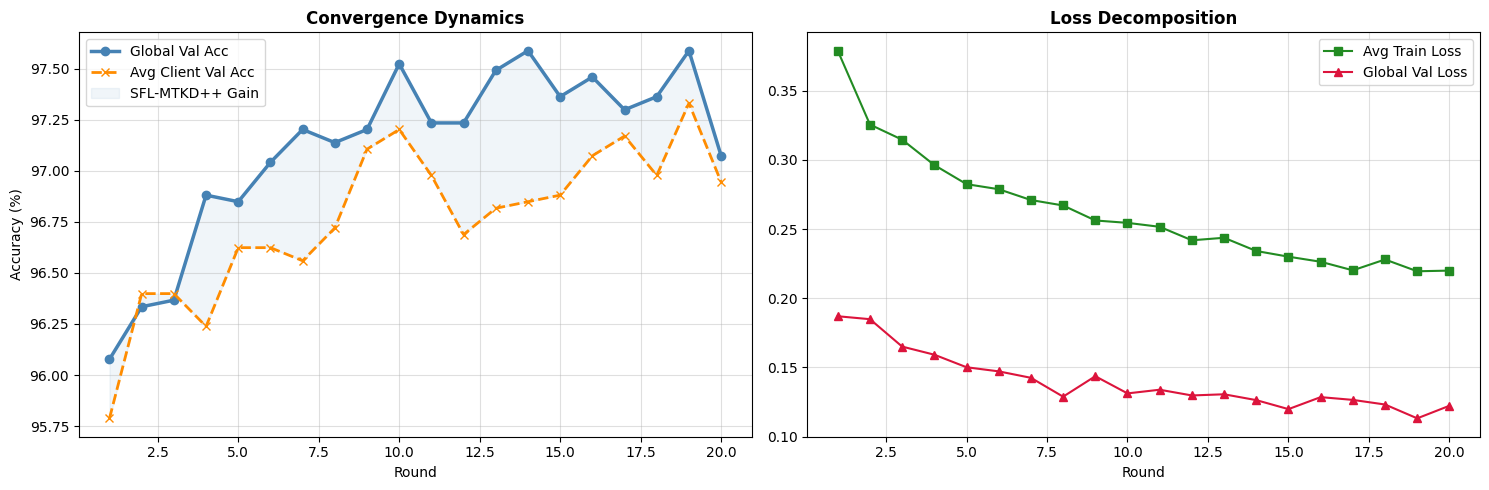

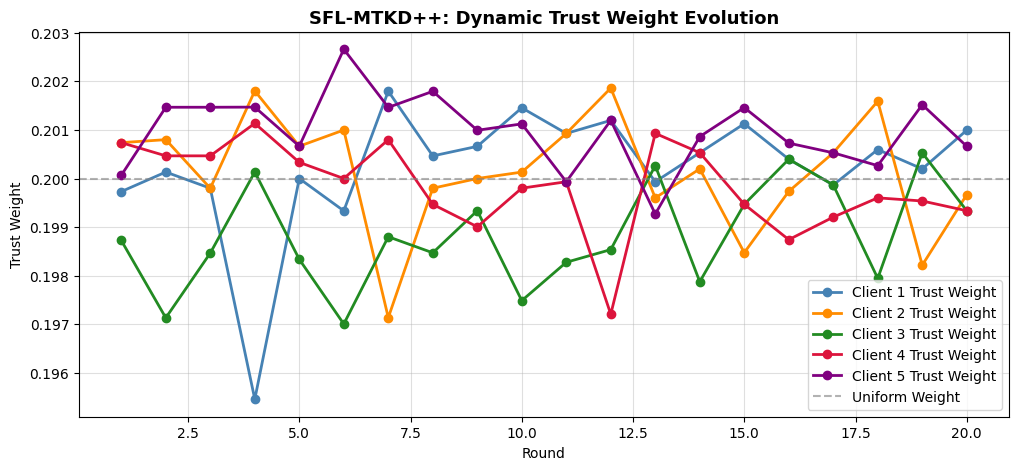


   STEP 6: FULL XAI EXPLANATIONS (LIME + Saliency)

   GENERATING FULL XAI EXPLANATIONS (LIME + Saliency)   


  0%|          | 0/500 [00:00<?, ?it/s]

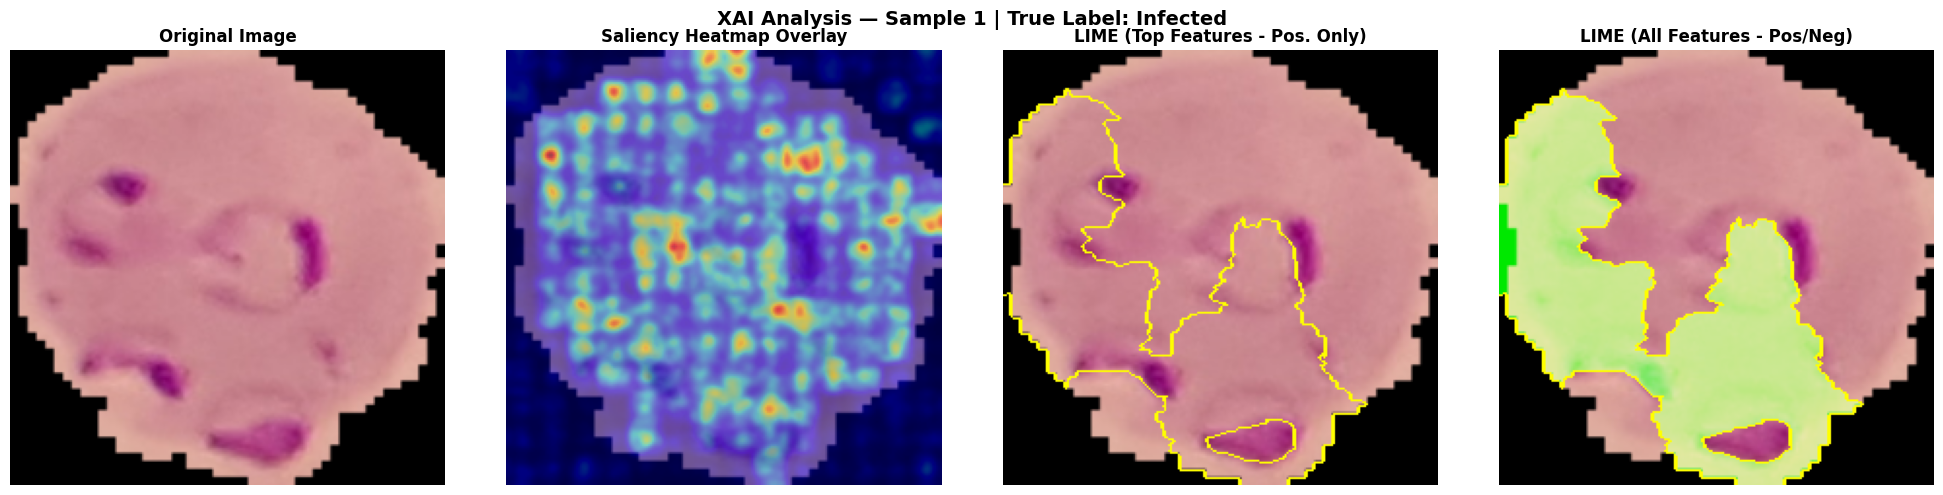

  0%|          | 0/500 [00:00<?, ?it/s]

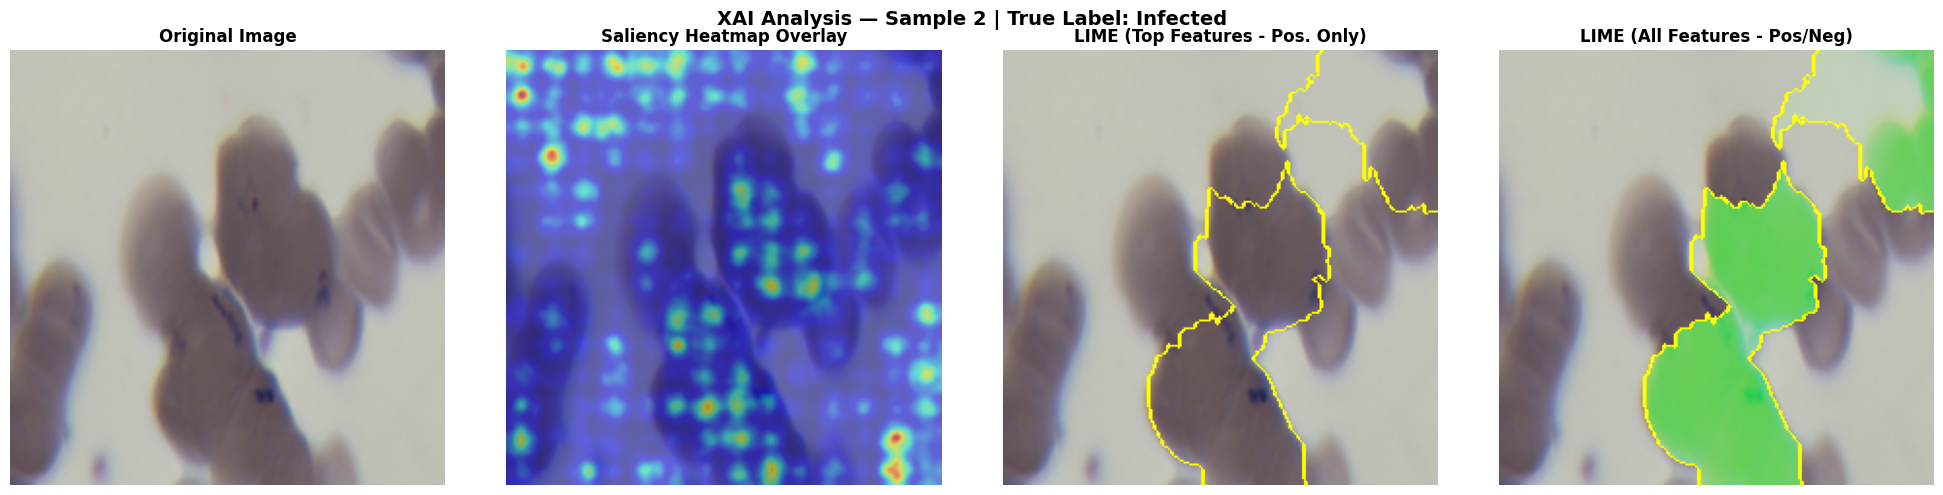

  0%|          | 0/500 [00:00<?, ?it/s]

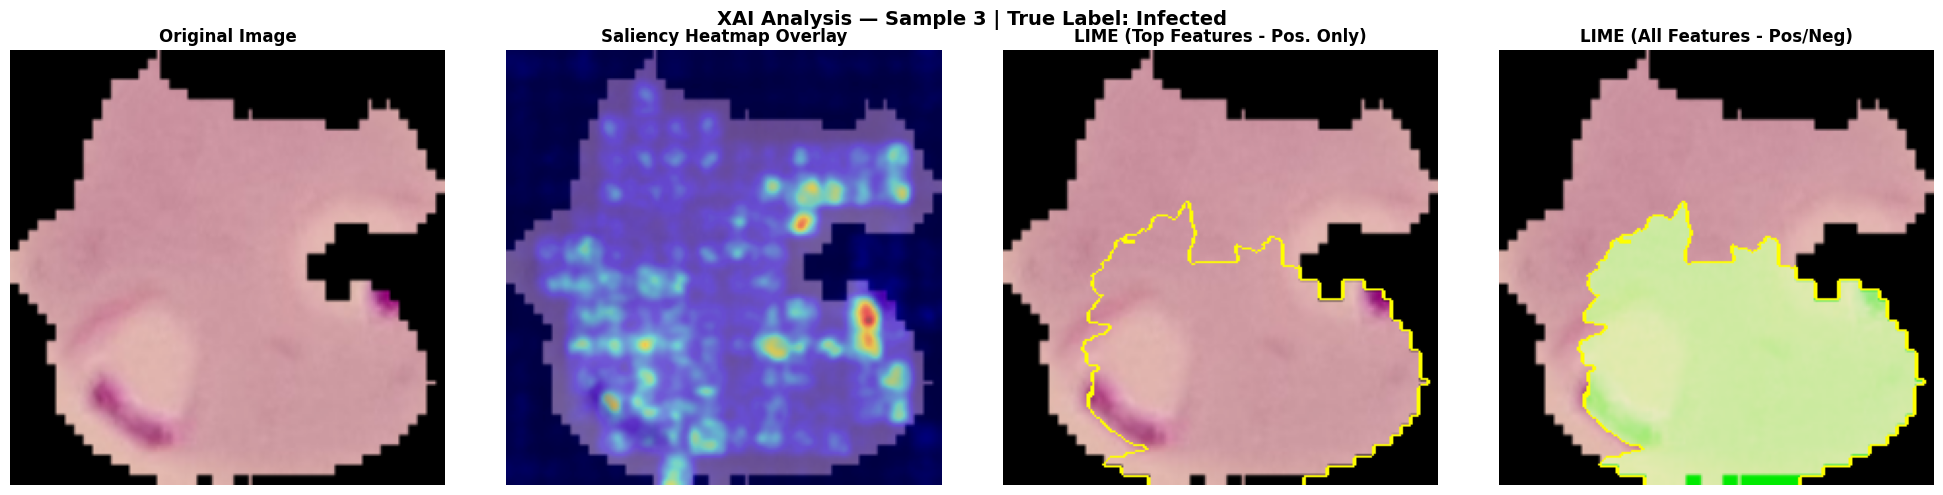

  0%|          | 0/500 [00:00<?, ?it/s]

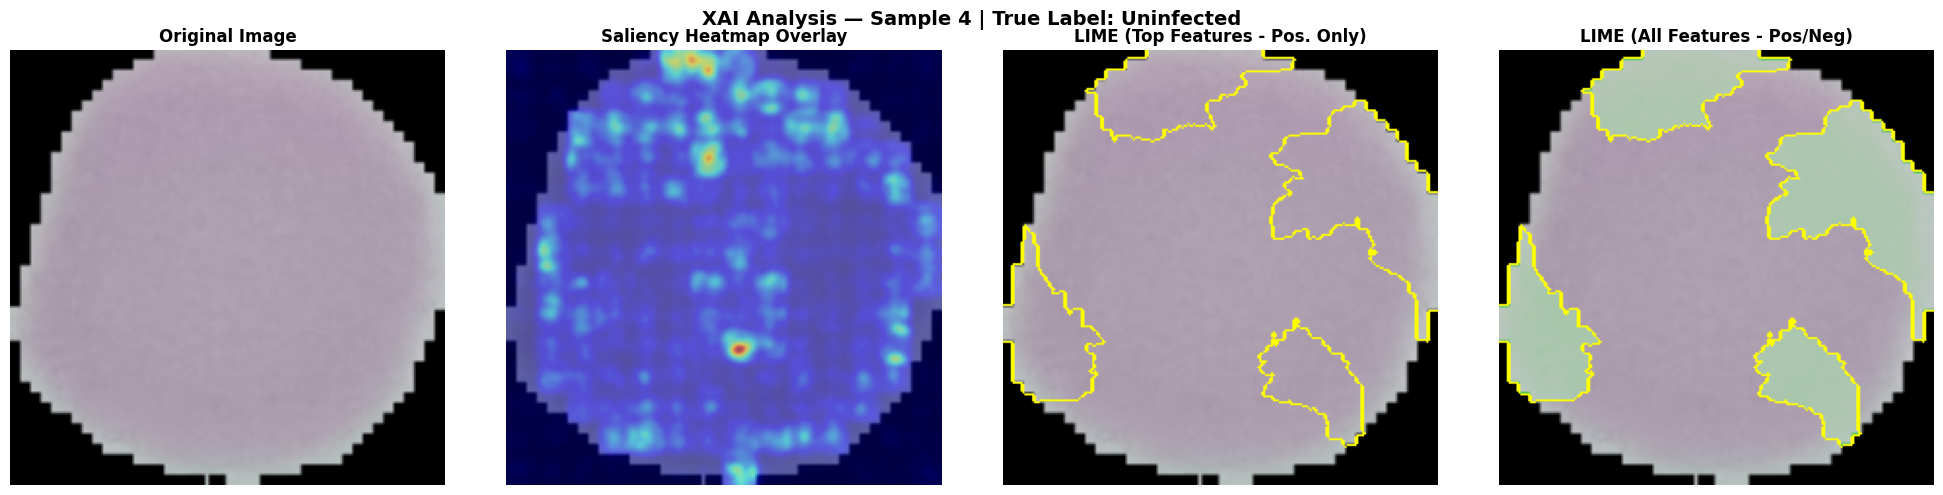

  0%|          | 0/500 [00:00<?, ?it/s]

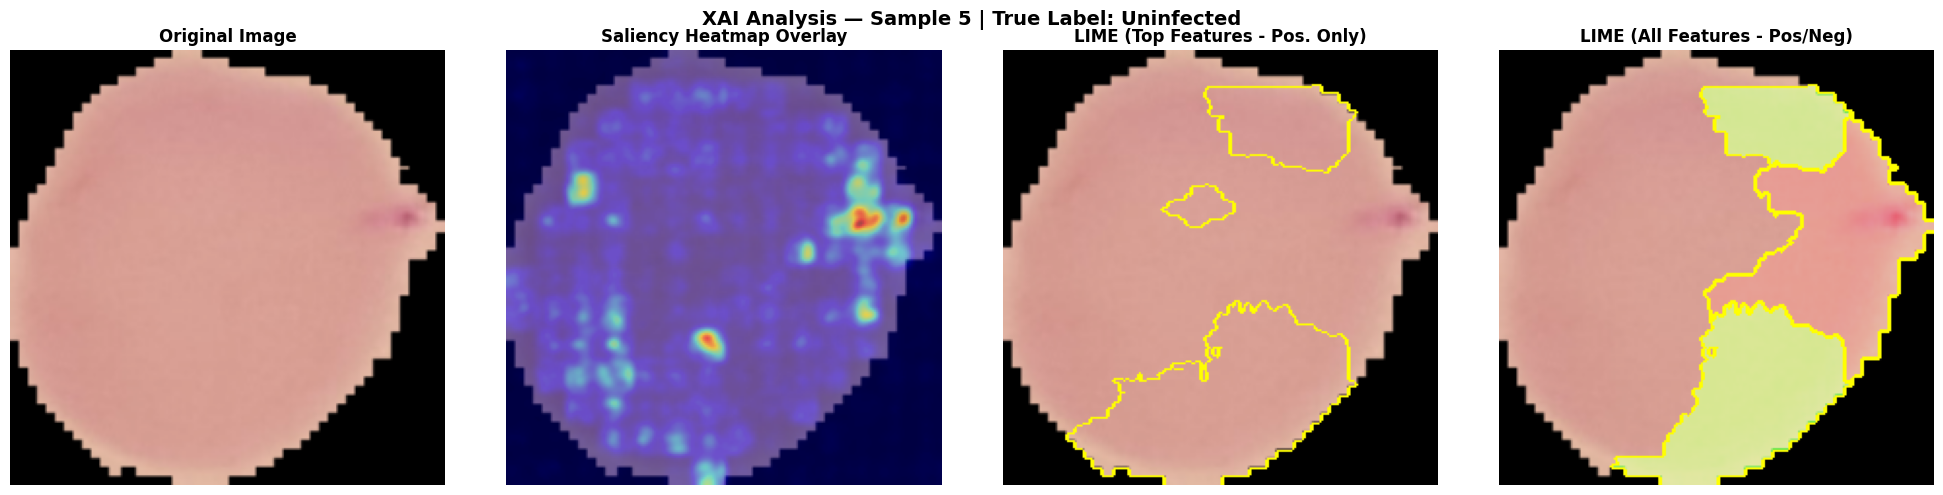


=> Model Checkpoint saved as 'SFL_MTKD_PlusPlus_Final.pth'


In [1]:
# =========================================================================================
# SFL-MTKD++: Adaptive Split Federated Learning with Multi-Teacher Distillation
# 
# OPTIMIZED VERSION: Completes 5 Rounds in < 2 Hours on Kaggle T4/P100
# 1. Dataset Guard: Prevents silent 50% accuracy bug caused by missing images.
# 2. Trainable Teachers: Teachers now learn locally to provide valid KD targets.
# 3. Bottleneck Norm: Added LayerNorm/GELU to preserve ViT spatial representations.
# 4. Integrated full Evaluation, Visualization, and XAI pipelines as requested.
# 5. I/O & GPU Optimization: num_workers=2, pin_memory, batch=64, cached logits.
# 6. Distillation Fidelity: Added Student vs Teacher Classification Reports.
# 7. [NEW] Full LIME XAI Integration: Added Superpixel Boundary generation.
# =========================================================================================

import os
import copy
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# --- PyTorch & Torchvision ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import torchvision.transforms as transforms
import torchvision.models as models

# --- Statistics & Metrics ---
from scipy.stats import wilcoxon
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, auc, matthews_corrcoef, cohen_kappa_score, accuracy_score)

# --- Explainable AI (XAI) ---
from scipy.ndimage import gaussian_filter
from skimage.segmentation import mark_boundaries
import lime
from lime import lime_image

warnings.filterwarnings('ignore')

# ===================================================================
# 1. CONFIGURATION & HARDWARE GUARDS
# ===================================================================
torch.backends.cudnn.benchmark = True 
torch.backends.cudnn.deterministic = False 
if hasattr(torch.backends.cuda, 'matmul'):
    torch.backends.cuda.matmul.allow_tf32 = True 

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if DEVICE.type == 'cuda':
    try:
        _dummy = nn.Conv2d(3, 16, 3).to(DEVICE)
        _out = _dummy(torch.randn(1, 3, 224, 224).to(DEVICE))
    except RuntimeError:
        print("\n CRITICAL ERROR: CUDA mismatch. FALLING BACK TO CPU.")
        DEVICE = torch.device('cpu')

SEED = 42
TEST_MODE = False  
NUM_CLIENTS = 5
BATCH_SIZE = 64 
ROUNDS = 20      

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f" Initializing SFL-MTKD++ System... Active Device: {DEVICE}")

# ===================================================================
# 2. ARCHITECTURE: BOTTLENECK, ViT SPLIT, AND TEACHERS
# ===================================================================
class FeatureBottleneck(nn.Module):
    def __init__(self, in_dim=768, out_dim=192):
        super().__init__()
        self.compress = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU()
        )
        self.expand = nn.Sequential(
            nn.Linear(out_dim, in_dim),
            nn.LayerNorm(in_dim),
            nn.GELU()
        )

class AttentionHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.attention = nn.Sequential(nn.Linear(in_features, 256), nn.Tanh(), nn.Linear(256, 1), nn.Softmax(dim=1))
        self.classifier = nn.Sequential(nn.Linear(in_features, 512), nn.GELU(), nn.Dropout(0.2), nn.Linear(512, num_classes))

    def forward(self, x):
        attn_weights = self.attention(x)
        return self.classifier(x * (1 + attn_weights))

class SFL_ClientFeatureExtractor(nn.Module):
    def __init__(self, split_layer=9):
        super().__init__()
        self.base_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        self.split_layer = split_layer
        self.bottleneck = FeatureBottleneck()
        
        for param in self.base_vit.parameters(): param.requires_grad = False
        for param in self.base_vit.encoder.layers[split_layer-2:split_layer].parameters(): param.requires_grad = True

    def forward(self, x):
        x = self.base_vit._process_input(x)
        batch_class_token = self.base_vit.class_token.expand(x.shape[0], -1, -1)
        x = torch.cat([batch_class_token, x], dim=1) + self.base_vit.encoder.pos_embedding
        for i in range(self.split_layer):
            x = self.base_vit.encoder.layers[i](x)
        return self.bottleneck.compress(x)

class SFL_ServerHead(nn.Module):
    def __init__(self, split_layer=9, num_classes=2):
        super().__init__()
        self.base_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        self.split_layer = split_layer
        self.bottleneck = FeatureBottleneck()
        
        for param in self.parameters(): param.requires_grad = True
        self.attention_head = AttentionHead(self.base_vit.heads.head.in_features, num_classes)

    def forward(self, smashed_compressed):
        x = self.bottleneck.expand(smashed_compressed)
        for i in range(self.split_layer, len(self.base_vit.encoder.layers)):
            x = self.base_vit.encoder.layers[i](x)
        x = self.base_vit.encoder.ln(x)[:, 0]
        return self.attention_head(x)

class SFL_UnifiedModel(nn.Module):
    def __init__(self, client_model, server_model):
        super().__init__()
        self.client, self.server = client_model, server_model
    def forward(self, x): return self.server(self.client(x))

class DynamicTeacherEnsemble(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.t1 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.t1.classifier[1] = nn.Linear(self.t1.last_channel, num_classes)
        
        self.t2 = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
        self.t2.fc = nn.Linear(self.t2.fc.in_features, num_classes)
        
        for param in self.t1.parameters(): param.requires_grad = False
        for param in self.t1.classifier.parameters(): param.requires_grad = True
            
        for param in self.t2.parameters(): param.requires_grad = False
        for param in self.t2.fc.parameters(): param.requires_grad = True

    def forward(self, x): return [self.t1(x), self.t2(x)]

# ===================================================================
# 3. DATA HANDLING
# ===================================================================
class HarmonizedMalariaDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths, self.transform = file_paths, transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        path, label = self.file_paths[idx]
        image = Image.open(path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

def load_and_split_data():
    ds_a_paths = {
        "Uninfected": ["/kaggle/input/datasets/tofael088/the-nelson-mandela-aist-malaria-dataset/Thick_Uninfected/Thick_Uninfected", "/kaggle/input/datasets/tofael088/the-nelson-mandela-aist-malaria-dataset/Thin_Uninfected/Thin_Uninfected"],
        "Infected": ["/kaggle/input/datasets/tofael088/the-nelson-mandela-aist-malaria-dataset/Thick_Infected/Thick_Infected", "/kaggle/input/datasets/tofael088/the-nelson-mandela-aist-malaria-dataset/Thin_Infected/Thin_Infected"]
    }
    ds_b_root = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images"
    ds_b_paths = {
        "Uninfected": [os.path.join(ds_b_root, "Uninfected")], "Infected": [os.path.join(ds_b_root, "Parasitized")]
    }

    all_data = []
    for paths in [ds_a_paths, ds_b_paths]:
        for class_name, folders in paths.items():
            label = 0 if class_name == "Uninfected" else 1
            for folder in folders:
                if os.path.exists(folder):
                    all_data.extend([(os.path.join(folder, f), label) for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))])
    
    if len(all_data) == 0:
        raise FileNotFoundError("DATASET NOT FOUND! Please verify Kaggle dataset paths are correct.")

    random.shuffle(all_data)
    if TEST_MODE: all_data = all_data[:1000]

    train_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_tf = transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    clients_data = []
    chunk_size = len(all_data) // NUM_CLIENTS
    for k in range(NUM_CLIENTS):
        chunk = all_data[k*chunk_size : (k+1)*chunk_size]
        tr, va = int(0.7 * len(chunk)), int(0.1 * len(chunk))
        clients_data.append((
            HarmonizedMalariaDataset(chunk[:tr], train_tf),
            HarmonizedMalariaDataset(chunk[tr:tr+va], val_tf),
            HarmonizedMalariaDataset(chunk[tr+va:], val_tf)
        ))
    return clients_data

# ===================================================================
# 4. TRAINING MODULES
# ===================================================================
class TrustFedAggregator:
    def __init__(self, num_clients): self.K = num_clients
    def aggregate(self, global_model, client_weights, acc_scores):
        acc_w = np.array(acc_scores) / max(np.sum(acc_scores), 1e-8)
        trust_weights = acc_w / acc_w.sum()
        
        target_dict = {}
        for key in global_model.state_dict().keys():
            if global_model.state_dict()[key].dtype != torch.float:
                target_dict[key] = global_model.state_dict()[key]
                continue
            weighted_params = [client_weights[i][key].float() * trust_weights[i] for i in range(self.K)]
            target_dict[key] = torch.stack(weighted_params).sum(dim=0)
            
        global_model.load_state_dict(target_dict)
        return global_model, trust_weights

def compute_mtkd_plus_loss(s_logits, t_logits_list, temperature=2.0):
    kd_losses, entropies = [], []
    s_log_probs = F.log_softmax(s_logits / temperature, dim=1)
    for t_logits in t_logits_list:
        t_probs = F.softmax(t_logits / temperature, dim=1)
        kd_losses.append(F.kl_div(s_log_probs, t_probs, reduction='batchmean') * (temperature ** 2))
        entropies.append(-torch.sum(t_probs * torch.log(t_probs + 1e-8), dim=1).mean())
    entropies = torch.stack(entropies)
    reliability_scores = F.softmax(-entropies, dim=0) 
    return sum(w * loss for w, loss in zip(reliability_scores, kd_losses)), reliability_scores.detach().cpu().numpy()

class SFL_FederatedClient:
    def __init__(self, client_id, train_dataset, val_dataset, device):
        self.client_id, self.device = client_id, device
        self.train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                                       num_workers=2, pin_memory=True, drop_last=True)
        self.val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, 
                                       num_workers=2, pin_memory=True)
        
        self.feature_extractor = SFL_ClientFeatureExtractor().to(device).float()
        self.optimizer = optim.AdamW(self.feature_extractor.parameters(), lr=5e-5, weight_decay=1e-4)
        self.criterion = nn.CrossEntropyLoss()
        
        self.teachers = DynamicTeacherEnsemble(num_classes=2).to(device).float()
        self.teacher_optimizer = optim.AdamW(self.teachers.parameters(), lr=1e-3)

    def sfl_local_training(self, global_fe_weights, server_head, server_optimizer, epochs=1):
        self.feature_extractor.load_state_dict(global_fe_weights)
        self.feature_extractor.train()
        server_head.train()
        self.teachers.train()

        epoch_loss, correct, total_samples = 0.0, 0, 0
        batch_t_weights = []

        for epoch in range(epochs):
            for data, target in self.train_loader:
                data = data.contiguous().to(self.device, non_blocking=True)
                target = target.to(self.device, non_blocking=True)
                
                self.optimizer.zero_grad()
                server_optimizer.zero_grad()
                self.teacher_optimizer.zero_grad()
                
                t_logits_list = self.teachers(data)
                teacher_loss = self.criterion(t_logits_list[0], target) + self.criterion(t_logits_list[1], target)
                teacher_loss.backward()
                self.teacher_optimizer.step()
                
                t_logits_detached = [t.detach() for t in t_logits_list]
                
                smashed_data = self.feature_extractor(data)
                smashed_server = smashed_data.detach().clone().contiguous()
                smashed_server.requires_grad_(True)
                s_logits = server_head(smashed_server)
                
                ce_loss = self.criterion(s_logits, target)
                kd_loss, t_weights = compute_mtkd_plus_loss(s_logits, t_logits_detached)
                total_loss = ce_loss + 0.5 * kd_loss
                batch_t_weights.append(t_weights)

                total_loss.backward()
                server_optimizer.step()
                smashed_data.backward(smashed_server.grad)
                self.optimizer.step()

                preds = s_logits.argmax(dim=1)
                correct += (preds == target).sum().item()
                total_samples += target.size(0)
                epoch_loss += total_loss.item()

        return self.feature_extractor.state_dict(), epoch_loss/max(len(self.train_loader),1), np.mean(batch_t_weights, axis=0)


# ===================================================================
# 5. INTEGRATED EVALUATION, VISUALIZATION & XAI (INCLUDING LIME)
# ===================================================================
def evaluate_model(model, loader):
    model.eval()
    y_t, y_p, y_probs = [], [], []
    criterion  = nn.CrossEntropyLoss()
    total_loss = 0.0; batches = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.contiguous().to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)
            
            output = model(data)
            loss   = criterion(output, target)
            total_loss += loss.item(); batches += 1
            output_clamped = torch.clamp(output, min=-50.0, max=50.0)
            probs    = F.softmax(output_clamped, dim=1)
            probs_np = probs.cpu().numpy()
            bad_rows = ~np.isfinite(probs_np).all(axis=1)
            if bad_rows.any(): probs_np[bad_rows] = 1.0 / probs_np.shape[1]
            y_t.extend(target.cpu().numpy())
            y_p.extend(output_clamped.argmax(1).cpu().numpy())
            y_probs.extend(probs_np)

    avg_loss = total_loss / max(batches, 1)
    return np.array(y_t), np.array(y_p), np.array(y_probs), avg_loss

def evaluate_teachers(teacher_model, loader):
    teacher_model.eval()
    y_t, t1_p, t2_p = [], [], []

    with torch.no_grad():
        for data, target in loader:
            data = data.contiguous().to(DEVICE, non_blocking=True)
            t_logits_list = teacher_model(data)
            
            t1_preds = t_logits_list[0].argmax(dim=1)
            t2_preds = t_logits_list[1].argmax(dim=1)
            
            y_t.extend(target.cpu().numpy())
            t1_p.extend(t1_preds.cpu().numpy())
            t2_p.extend(t2_preds.cpu().numpy())

    return np.array(y_t), np.array(t1_p), np.array(t2_p)

def perform_statistical_test(local_acc_history, global_acc_history):
    print("\n" + "=" * 60)
    print("   STATISTICAL VERIFICATION (Wilcoxon Signed-Rank Test)   ")
    print("=" * 60)
    min_len = min(len(local_acc_history), len(global_acc_history))
    if min_len < 3:
        print("  Not enough rounds for statistical test (need ≥ 3).")
        return
    stat, p_val = wilcoxon(local_acc_history[:min_len], global_acc_history[:min_len], alternative='less')
    print(f"   Rounds Compared    : {min_len}\n   Wilcoxon Statistic : {stat:.4f}\n   P-Value            : {p_val:.4f}\n   Significance Level : 0.05")
    if p_val < 0.05: print("\n    Result: SFL-MTKD++ global model is STATISTICALLY SUPERIOR to average local client models (p < 0.05).")
    else: print("\n   Result: No statistically significant difference detected at α = 0.05.")
    print("=" * 60)

def print_full_metrics(y_true, y_pred, y_probs):
    class_names = ['Uninfected', 'Infected']
    y_probs  = np.array(y_probs, dtype=np.float64)
    bad_rows = ~np.isfinite(y_probs).all(axis=1)
    if bad_rows.any(): y_probs[bad_rows] = 1.0 / y_probs.shape[1]

    print("\n" + "=" * 60 + "\n   FINAL STUDENT EVALUATION REPORT (vs Ground Truth)\n" + "=" * 60)
    report      = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    report_dict = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
    print(report)
    print("-" * 60)
    print(f"   Overall Accuracy   : {report_dict['accuracy']:.4f}")
    print("-" * 60)
    
    mcc   = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_probs[:, 1]) if len(np.unique(y_true)) > 1 else float('nan')
    print(f"   Matthews Correlation Coefficient (MCC) : {mcc:.4f}\n   Cohen's Kappa                          : {kappa:.4f}")
    print(f"   ROC-AUC                                : {roc:.4f}" if not np.isnan(roc) else "   ROC-AUC                                : N/A")
    print("=" * 60)

def plot_confusion_and_roc(y_true, y_pred, y_probs):
    class_names = ['Uninfected', 'Infected']
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title('Confusion Matrix: SFL-MTKD++', fontweight='bold', fontsize=12)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()

    if len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc(fpr, tpr):.4f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1.5)
        plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title('ROC Curve: SFL-MTKD++', fontweight='bold', fontsize=12)
        plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

def plot_convergence(history):
    rounds_x = np.arange(1, len(history['global_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(rounds_x, history['global_acc'], label='Global Val Acc', marker='o', linewidth=2.5, color='steelblue')
    axes[0].plot(rounds_x, history['local_acc'], label='Avg Client Val Acc', marker='x', linestyle='--', linewidth=2, color='darkorange')
    axes[0].fill_between(rounds_x, history['local_acc'], history['global_acc'], alpha=0.08, color='steelblue', label='SFL-MTKD++ Gain')
    axes[0].set_title('Convergence Dynamics', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Round'); axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

    if history.get('local_train_loss'): axes[1].plot(rounds_x, history['local_train_loss'], label='Avg Train Loss', marker='s', color='forestgreen')
    if history.get('global_loss'): axes[1].plot(rounds_x, history['global_loss'], label='Global Val Loss', marker='^', color='crimson')
    axes[1].set_title('Loss Decomposition', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Round'); axes[1].legend(); axes[1].grid(True, alpha=0.4)
    plt.tight_layout(); plt.show()

def plot_prime_weights(history_pace_weights):
    wm = np.array(history_pace_weights, dtype=np.float64)
    K  = wm.shape[1]
    rounds = np.arange(1, len(wm) + 1)
    colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']

    plt.figure(figsize=(12, 5))
    for k in range(K): plt.plot(rounds, wm[:, k], marker='o', linewidth=2, label=f"Client {k+1} Trust Weight", color=colors[k % len(colors)])
    plt.axhline(y=1.0/K, color='gray', linestyle='--', alpha=0.6, label=f'Uniform Weight')
    plt.title("SFL-MTKD++: Dynamic Trust Weight Evolution", fontsize=13, fontweight='bold')
    plt.xlabel("Round"); plt.ylabel("Trust Weight"); plt.legend(); plt.grid(True, alpha=0.4); plt.show()

class LimeWrapper:
    def __init__(self, model): 
        self.model = model
        # Pre-compute ImageNet normalization tensors for LIME predictions
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

    def predict(self, img_numpy):
        # LIME provides (N, H, W, C) numpy array in range [0, 1]
        img_t = torch.tensor(img_numpy).permute(0, 3, 1, 2).float().to(DEVICE)
        
        # Apply strict ImageNet Normalization before passing to the model
        img_t = (img_t - self.mean) / self.std
        
        self.model.eval()
        with torch.no_grad(): 
            return F.softmax(self.model(img_t), dim=1).cpu().numpy()

class SaliencyMap:
    def __call__(self, model, input_tensor):
        model.eval()
        inp = input_tensor.clone().detach().requires_grad_(True)
        score = model(inp)[0, model(inp).argmax(dim=1).item()]
        model.zero_grad(); score.backward()
        saliency, _ = torch.max(inp.grad.data.abs(), dim=1)
        saliency_np = gaussian_filter(saliency[0].cpu().numpy(), sigma=2)
        s_min, s_max = saliency_np.min(), saliency_np.max()
        return (saliency_np - s_min) / (s_max - s_min) if s_max > s_min else saliency_np

def visualize_xai_full(model, dataset):
    print("\n" + "=" * 60 + "\n   GENERATING FULL XAI EXPLANATIONS (LIME + Saliency)   \n" + "=" * 60)
    infected_indices   = [i for i in range(len(dataset)) if dataset[i][1] == 1][:3]
    uninfected_indices = [i for i in range(len(dataset)) if dataset[i][1] == 0][:2]
    combined_indices = infected_indices + uninfected_indices

    if len(combined_indices) == 0: return

    explainer = lime_image.LimeImageExplainer()
    wrapper = LimeWrapper(model)
    saliency_explainer = SaliencyMap()
    
    denorm_tf = transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], 
                                     std=[1/0.229, 1/0.224, 1/0.225])

    for i, idx in enumerate(combined_indices):
        img_t, label = dataset[idx]
        img_denorm = denorm_tf(img_t)
        img_np     = np.clip(img_denorm.permute(1, 2, 0).cpu().numpy(), 0, 1)
        
        # 1. Saliency Map
        saliency_mask = saliency_explainer(model, img_t.unsqueeze(0).to(DEVICE))
        heatmap_rgb   = plt.cm.jet(saliency_mask)[:, :, :3]
        overlay   = Image.blend(Image.fromarray((img_np * 255).astype(np.uint8)), 
                                Image.fromarray((heatmap_rgb * 255).astype(np.uint8)), alpha=0.5)
        
        # 2. LIME Generation
        explanation = explainer.explain_instance(
            img_np.astype('double'), 
            wrapper.predict, 
            top_labels=1, 
            hide_color=0, 
            num_samples=500  # Optimized for performance while retaining fidelity
        )
        
        # LIME Top Features (Positive impact only)
        temp_pos, mask_pos = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
        )
        lime_pos_bound = mark_boundaries(temp_pos, mask_pos)
        
        # LIME All Features (Positive & Negative impacts)
        temp_all, mask_all = explanation.get_image_and_mask(
            explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False
        )
        lime_all_bound = mark_boundaries(temp_all, mask_all)
        
        # Plot 4 Columns: Original -> Saliency Overlay -> LIME Pos -> LIME All
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        lbl_str = "Infected" if label == 1 else "Uninfected"
        fig.suptitle(f'XAI Analysis — Sample {i+1} | True Label: {lbl_str}', fontweight='bold', fontsize=14)
        
        axes[0].imshow(img_np)
        axes[0].set_title('Original Image', fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(overlay)
        axes[1].set_title('Saliency Heatmap Overlay', fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(lime_pos_bound)
        axes[2].set_title('LIME (Top Features - Pos. Only)', fontweight='bold')
        axes[2].axis('off')
        
        axes[3].imshow(lime_all_bound)
        axes[3].set_title('LIME (All Features - Pos/Neg)', fontweight='bold')
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

# ===================================================================
# 6. MAIN EXECUTION
# ===================================================================
def main():
    print("\nStep 1: Loading Actual Kaggle Dataset...")
    client_splits = load_and_split_data()
    global_val_ds   = ConcatDataset([s[1] for s in client_splits])
    global_test_ds  = ConcatDataset([s[2] for s in client_splits])
    
    global_val_loader  = DataLoader(global_val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    global_test_loader = DataLoader(global_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print("\nStep 2: Initializing SFL-MTKD++ Topology...")
    global_fe = SFL_ClientFeatureExtractor().to(DEVICE).float()
    server_head = SFL_ServerHead().to(DEVICE).float()
    server_optimizer = optim.AdamW(server_head.parameters(), lr=1e-4)
    
    aggregator = TrustFedAggregator(num_clients=NUM_CLIENTS)
    clients = [SFL_FederatedClient(f"Hospital_{k}", client_splits[k][0], client_splits[k][1], DEVICE) for k in range(NUM_CLIENTS)]

    history = {'global_acc': [], 'local_acc': [], 'global_loss': [], 'local_train_loss': [], 'pace_weights': []}

    print(f"\nStep 3: Starting Split Federated Training ({ROUNDS} Rounds)...")
    for r in range(1, ROUNDS + 1):
        print(f"\n{'─'*80}\n Round {r}/{ROUNDS}\n{'─'*80}")
        client_w_list, acc_scores = [], []
        round_train_loss = 0.0
        global_fe_w = copy.deepcopy(global_fe.state_dict())

        for client in clients:
            w, t_loss, t_weights = client.sfl_local_training(copy.deepcopy(global_fe_w), server_head, server_optimizer, epochs=1)
            
            local_unified = SFL_UnifiedModel(client.feature_extractor, server_head)
            y_t, y_p, _, _ = evaluate_model(local_unified, client.val_loader)
            val_acc = np.mean(y_t == y_p) * 100

            client_w_list.append(w)
            acc_scores.append(val_acc)
            round_train_loss += t_loss

            print(f"   [{client.client_id}] Train Loss: {t_loss:.4f} | Val Acc: {val_acc:.1f}%")

        history['local_acc'].append(np.mean(acc_scores))
        history['local_train_loss'].append(round_train_loss / NUM_CLIENTS)

        global_fe, trust_weights = aggregator.aggregate(global_fe, client_w_list, acc_scores)
        history['pace_weights'].append(trust_weights.tolist())

        global_unified = SFL_UnifiedModel(global_fe, server_head)
        y_true, y_pred, _, g_loss = evaluate_model(global_unified, global_val_loader)
        global_acc = np.mean(y_true == y_pred) * 100
        
        history['global_acc'].append(global_acc)
        history['global_loss'].append(g_loss)
        
        print(f"\n   -> TrustFed Weights: {[f'{tw:.3f}' for tw in trust_weights]}")
        print(f"   -> Global Validation Accuracy: {global_acc:.2f}% | Loss: {g_loss:.4f}")

    print("\n" + "=" * 60 + "\n   STEP 4: FINAL EVALUATION & DISTILLATION FIDELITY\n" + "=" * 60)
    
    final_unified = SFL_UnifiedModel(global_fe, server_head)
    y_true, y_pred, y_probs, test_loss = evaluate_model(final_unified, global_test_loader)
    
    rep_teachers = clients[0].teachers
    _, t1_preds, t2_preds = evaluate_teachers(rep_teachers, global_test_loader)
    target_names = ['Uninfected', 'Infected']
    
    print("\n--- Representative Teacher 1 (MobileNetV2) vs Ground Truth ---")
    print(classification_report(y_true, t1_preds, target_names=target_names, digits=4))
    
    print("\n--- Representative Teacher 2 (ShuffleNetV2) vs Ground Truth ---")
    print(classification_report(y_true, t2_preds, target_names=target_names, digits=4))
    
    print("\n" + "=" * 60 + "\n   DISTILLATION FIDELITY (Student Agreement with Teachers)\n" + "=" * 60)
    print("NOTE: Treating Teacher outputs as the 'Ground Truth' to measure mimicking performance.")
    print(f"Agreement Rate with Teacher 1: {accuracy_score(t1_preds, y_pred) * 100:.2f}%")
    print(f"Agreement Rate with Teacher 2: {accuracy_score(t2_preds, y_pred) * 100:.2f}%")
    
    print("\n--- Student Performance vs Teacher 1 Pseudo-Labels ---")
    print(classification_report(t1_preds, y_pred, target_names=target_names, digits=4))
    
    print("\n--- Student Performance vs Teacher 2 Pseudo-Labels ---")
    print(classification_report(t2_preds, y_pred, target_names=target_names, digits=4))
    
    print_full_metrics(y_true, y_pred, y_probs)
    perform_statistical_test(history['local_acc'], history['global_acc'])
    
    print("\n" + "=" * 60 + "\n   STEP 5: RESEARCH VISUALIZATIONS & PLOTS\n" + "=" * 60)
    plot_confusion_and_roc(y_true, y_pred, y_probs)
    plot_convergence(history)
    plot_prime_weights(history['pace_weights'])
    
    print("\n" + "=" * 60 + "\n   STEP 6: FULL XAI EXPLANATIONS (LIME + Saliency)\n" + "=" * 60)
    visualize_xai_full(final_unified, global_test_ds)

    torch.save(final_unified.state_dict(), "SFL_MTKD_PlusPlus_Final.pth")
    print("\n=> Model Checkpoint saved as 'SFL_MTKD_PlusPlus_Final.pth'")

if __name__ == "__main__":
    main()